# Phase 4: Automated System Evaluation (RAGAS)

Now that our Zero Trust RAG architecture is built, it is time to test how well it actually performs.

In this phase, we are running an automated evaluation using the **RAGAS (Retrieval-Augmented Generation Assessment)** framework. To keep our data completely private and adhere strictly to Zero Trust principles, this entire evaluation is executed **100% locally**. We will not send any data to external cloud APIs; instead, we are using our local Llama-3 model to both generate the answers and act as the "judge" to grade them.

### What to expect in this notebook:

* **Step 1: Installing Dependencies** – Setting up the required RAGAS testing libraries.
* **Step 2: Mounting Google Drive and Authenticating Hugging face token** – Connecting our storage and securely accessing our models.
* **Step 3: Initiating/Loading Retriever and Generator** – Waking up our Vector Database and bringing the Llama-3 model back online in the GPU.
* **Step 4: Setting up the questions to test my RAG system.** – Defining 10 specific, high-level questions based on the NIST 800-207 guidelines.
* **Step 5: Running the Test Cases** – Feeding the questions into the pipeline to record exactly which text chunks are retrieved and what answers are generated.
* **Step 6: The Fully Local Evaluation Pipeline** – Using Llama-3 to score our system against four strict metrics (Context Recall, Context Precision, Answer Relevancy, and Faithfulness) and saving the results to a CSV report.
* **Step 7: Plotting the graphs** – Visualizing our final evaluation data to clearly see where the architecture excels and where it faces real-world challenges.

# Step 1: Installing Dependencies

In [1]:
# Install core pipeline tools, forcing LangChain to stay on the stable version
!pip install -q transformers accelerate bitsandbytes "langchain<0.2.0" "langchain-community<0.2.0" "langchain-core<0.2.0" langchain-huggingface networkx huggingface_hub sentence-transformers chromadb ragas datasets matplotlib seaborn pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.1/303.1 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 115.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.

# Step 2: Mouting Google Drive and Authenticating Hugging face token


In [11]:
# Step 2: Mouting Google Drive and Authenticating Hugging face token
import os

import sys
import pickle
from google.colab import drive, userdata
from huggingface_hub import login

# 1. Mount Drive
drive.mount('/content/drive')

# Add project path so Python can find your .py files
project_path = '/content/drive/My Drive/ZTA_Project'
sys.path.append(project_path)

import os
from google.colab import userdata
from huggingface_hub import login

print("Initiating Hugging Face Authentication...")

# Safely retrieve the token from Colab Secrets
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    hf_token = None

if not hf_token:
    print("❌ ERROR: Colab cannot find your 'HF_TOKEN'.")
    print("Please click the Key icon on the left, add/enable HF_TOKEN, and run this again.")
else:
    # Force the token into the system environment variables
    os.environ["HF_TOKEN"] = hf_token
    os.environ["HUGGING_FACE_HUB_TOKEN"] = hf_token

    # Execute the login
    login(token=hf_token, add_to_git_credential=True)
    print("✅ Authentication Successful! You can now load the Advanced Generator.")
print("Developer Log: Drive mounted and Authentication successful.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Initiating Hugging Face Authentication...


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Authentication Successful! You can now load the Advanced Generator.
Developer Log: Drive mounted and Authentication successful.


In [7]:
!pip install -q "numpy<2.0.0"

# Step 3: Initiating/Loading Retriever and Generator


In [2]:
# Step 3: Initiating/Loading Retriever and Generator
from retrieval import AdvancedRetriever
from generator import AdvancedGenerator

# 1. Load the Knowledge Graph
graph_path = os.path.join(project_path, 'zta_knowledge_graph.gpickle')
with open(graph_path, 'rb') as f:
    G = pickle.load(f)

# 2. Initialize Retriever
db_path = '/content/drive/My Drive/ZTA_Project/chroma_db_bge'
retriever = AdvancedRetriever(db_path)

# 3. Initialize Generator (Llama 3)
generator = AdvancedGenerator(G)

print("Developer Log: System Architecture Online.")

Initializing Advanced Retriever on CUDA...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'repetition_penalty'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Developer Log: System Architecture Online.


# Step 4: Setting up the questions to test our RAG system.


In [3]:
# Step 4: Setting up the questions to test our RAG system.
import pandas as pd

# Define the Evaluation Dataset (10 Questions)
# 'question': What the user asks
# 'ground_truth': The strictly correct, NIST-compliant answer
eval_data = {
    "question": [
        # Network & Lateral Movement
        "How do I prevent lateral movement if a remote worker's laptop is compromised?",
        "What is the purpose of a Trusted Internet Connection (TIC)?",
        "How does Zero Trust Architecture treat internal versus external networks?",
        "What role does micro-segmentation play in a Zero Trust environment?",

        # Architecture & Components (PE, PA, PEP)
        "What are the core components of the Zero Trust logical architecture according to NIST 800-207?",
        "What is the specific role of a Policy Enforcement Point (PEP)?",
        "What is the function of the Policy Engine (PE) in the trust algorithm?",

        # Access & Policy
        "How should access to individual enterprise resources be granted in ZTA?",
        "Why is device posture evaluation important before granting access to a resource?",
        "How does Zero Trust apply the principle of least privilege?"
    ],
    "ground_truth": [
        "To prevent lateral movement, implement strict access controls on the internal network, use micro-segmentation, and enforce physical security like lockable casings to prevent hardware theft.",
        "A TIC provides a strong internet gateway to block attackers from the internet, though it is less useful for detecting internal unauthorized movement.",
        "ZTA assumes that no network is implicitly trusted. The internal network is considered just as hostile as an external network, and location alone does not grant access privileges.",
        "Micro-segmentation divides the network into small, isolated zones to strictly control access to specific workloads, thereby containing breaches and preventing unauthorized lateral movement.",
        "The core components include the Policy Engine (PE) and Policy Administrator (PA), which together form the Policy Decision Point (PDP), and the Policy Enforcement Point (PEP).",
        "The PEP is responsible for enabling, monitoring, and eventually terminating connections between a subject and an enterprise resource, acting upon the commands of the Policy Decision Point.",
        "The Policy Engine computes the trust score and makes the ultimate decision to grant, deny, or revoke access to a resource based on enterprise policy and external threat intelligence.",
        "Access should be granted on a per-session basis, evaluating the subject, device, and context dynamically before establishing the connection to the specific resource.",
        "Device posture is continuously evaluated to ensure the asset meets enterprise security requirements (like being fully patched) to prevent compromised devices from accessing sensitive resources.",
        "ZTA enforces least privilege by granting subjects only the minimum access rights necessary to perform their specific tasks, and only for the duration of that task."
    ]
}

print(f"Developer Log: Evaluation dataset loaded with {len(eval_data['question'])} test cases.")

Developer Log: Evaluation dataset loaded with 10 test cases.


# Step 5: Running the Test Cases
Before we can grade the system, we need to see how it actually performs. In this step, we feed all 10 of our test questions into our local Llama-3 pipeline. We record exactly which text chunks the database retrieved and the final answer the AI generated, and then package it all into a format that the RAGAS grader understands.

In [4]:
 # Step 5: Running the Test Cases
# Lists to store our pipeline's actual outputs
system_answers = []
system_contexts = []

print("Running pipeline tests. Please wait...\n")

for q in eval_data["question"]:
    # 1. Retrieve the chunks
    retrieval_results = retriever.retrieve_and_rerank(q)

    # Ragas requires context as a list of strings
    contexts = [doc.page_content for doc in retrieval_results['documents']]
    system_contexts.append(contexts)

    # 2. Generate the answer
    answer = generator.generate_answer(q, retrieval_results['documents'])
    system_answers.append(answer)
    print(f"Tested: {q}")

# Combine everything into a format RAGAS understands (HuggingFace Dataset format)
eval_data["answer"] = system_answers
eval_data["contexts"] = system_contexts

from datasets import Dataset
ragas_dataset = Dataset.from_dict(eval_data)
print("\nDeveloper Log: Pipeline outputs recorded and ready for scoring.")

Running pipeline tests. Please wait...



Passing `generation_config` together with generation-related arguments=({'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tested: How do I prevent lateral movement if a remote worker's laptop is compromised?


Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tested: What is the purpose of a Trusted Internet Connection (TIC)?
Tested: How does Zero Trust Architecture treat internal versus external networks?


...

Tested: How should access to individual enterprise resources be granted in ZTA?


Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tested: Why is device posture evaluation important before granting access to a resource?


Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Tested: How does Zero Trust apply the principle of least privilege?

Developer Log: Pipeline outputs recorded and ready for scoring.


In [ ]:
# Fix for RAGAS / LangChain dependency conflict
!pip install -q langchain-google-vertexai langchain-community --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.8/354.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.2/375.2 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.9/934.9 kB 76.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the

# Step 6: The Fully Local Evaluation Pipeline
This is the main testing engine. To keep our data completely private and adhere to Zero Trust principles, we are using our local Llama-3 model as the "Judge" to grade the answers instead of a cloud API.

This script will loop through our test questions one by one. For each question, it will fetch the chunks, generate the answer, calculate the four RAGAS metrics, and print the results live on the screen. Finally, it saves everything into a detailed CSV report.

In [5]:
# Step 6: The Fully Local Evaluation Pipeline
import pandas as pd
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
from ragas.run_config import RunConfig
from langchain_huggingface import HuggingFacePipeline
from transformers import pipeline

# Fix for RAGAS / LangChain dependency conflict by downgrading langchain-community
# This addresses ModuleNotFoundError for 'langchain_community.chat_models.vertexai'
!pip install -q langchain-community==0.0.29

print("Configuring the robust Local Judge LLM...")

# 1. Setup the Judge Pipeline with full memory limits (No speed hacks)
judge_pipeline = pipeline(
    "text-generation",
    model=generator.model,
    tokenizer=generator.tokenizer,
    max_new_tokens=2048,            # Restored to 2048 to prevent JSON cutoff
    temperature=0.1,                # Low temperature for highly analytical grading
    return_full_text=False,
    pad_token_id=generator.tokenizer.eos_token_id
)

llm_judge = HuggingFacePipeline(pipeline=judge_pipeline)
embedder = retriever.embeddings

print("Initiating Live-Streaming RAGAS Evaluation...\n")

all_results = []

# 2. Loop through the dataset one question at a time
for i in range(len(eval_data["question"])):
    q = eval_data["question"][i]
    gt = eval_data["ground_truth"][i]

    print(f"==================================================")
    print(f"EVALUATING TEST CASE {i+1} OF {len(eval_data['question'])}")
    print(f"==================================================")
    print(f"USER ASKED: {q}\n")

    # --- STEP A: RETRIEVAL & GENERATION ---
    retrieval_results = retriever.retrieve_and_rerank(q)
    contexts = [doc.page_content for doc in retrieval_results['documents']]
    answer = generator.generate_answer(q, retrieval_results['documents'])

    print("--- 📚 RETRIEVED CHUNKS (Top 3 Snippets) ---")
    for j, c in enumerate(contexts, 1):
        print(f"[{j}]: {c[:200]}...\n")

    print("--- 🤖 ARCHITECT ANSWER ---")
    print(f"{answer}\n")
    print("--- 📊 CALCULATING RAGAS METRICS (Please wait...) ---")

    # --- STEP B: RAGAS GRADING ---
    # Package this single question into a dataset
    single_item = {
        "question": [q],
        "ground_truth": [gt],
        "contexts": [contexts],
        "answer": [answer]
    }
    single_dataset = Dataset.from_dict(single_item)

    try:
        # Evaluate just this ONE question
        result = evaluate(
            single_dataset,
            metrics=[context_precision, context_recall, faithfulness, answer_relevancy],
            llm=llm_judge,
            embeddings=embedder,
            raise_exceptions=False,
            # max_workers=1 ensures it doesn't try to multitask and crash the GPU
            run_config=RunConfig(timeout=1200, max_workers=1)
        )

        # Extract scores
        scores = result.to_pandas().iloc[0]

        print("\n✅ SCORES FOR TEST CASE", i+1)
        print(f"Context Precision: {scores.get('context_precision', float('nan')):.3f}")
        print(f"Context Recall:    {scores.get('context_recall', float('nan')):.3f}")
        print(f"Faithfulness:      {scores.get('faithfulness', float('nan')):.3f}")
        print(f"Answer Relevancy:  {scores.get('answer_relevancy', float('nan')):.3f}\n")

        # Save to our master list
        all_results.append({
            "User Query": q,
            "Retrieved Passages (Top-3)": "\n\n---\n\n".join(contexts),
            "Guideline Output (Model Answer)": answer,
            "Context Relevance (Precision)": scores.get('context_precision'),
            "Context Recall": scores.get('context_recall'),
            "Faithfulness": scores.get('faithfulness'),
            "Answer Relevance": scores.get('answer_relevancy')
        })

    except Exception as e:
        print(f"\n❌ ERROR ON TEST CASE {i+1}: {e}\n")

# --- STEP C: EXPORTING DATA ---
print("==================================================")
print("ALL TESTS COMPLETE. EXPORTING DATA...")
print("==================================================")
final_report = pd.DataFrame(all_results)
final_report.to_csv('ZTA_Detailed_Evaluation_Report.csv', index=False)
print("Success! Data securely saved to 'ZTA_Detailed_Evaluation_Report.csv' in your Colab files.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipykernel_2976/1169460238.py:4: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_2976/1169460238.py:4: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.1.20 requires langchain-community<0.1,>=0.0.38, but you have langchain-community 0.0.29 which is incompatible.


Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Configuring the robust Local Judge LLM...
Initiating Live-Streaming RAGAS Evaluation...

EVALUATING TEST CASE 1 OF 10
USER ASKED: How do I prevent lateral movement if a remote worker's laptop is compromised?



You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Both `max_new_tokens` (=512) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- 📚 RETRIEVED CHUNKS (Top 3 Snippets) ---
[1]: possible.  
Zero trust provides a set of principles and concepts around moving the PDP/PEPs closer to the 
resource. The idea is to explicitly authenticate and authorize all subjects, assets and workf...

[2]: perimeterization evolved and improved into the larger concept of zero trust, which was later 
coined by John Kindervag
1 while at Forrester.2 Zero trust then became the term used to describe 
various ...

[3]: 1.2 Structure of This Document ............................................................................ 2 
2 Zero Trust Basics ........................................................................

--- 🤖 ARCHITECT ANSWER ---
Based on the provided context and graph facts, I can infer that Zero Trust applies the principle of least privilege through its core tenet of "never trust" or "trust no one". This means that every access request is evaluated on a per-transaction basis, and only the minimum necessary privileges are 

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

Both `max_new_tokens` (=2048) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=2048) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=2048) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=2048) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene


✅ SCORES FOR TEST CASE 10
Context Precision: 0.500
Context Recall:    1.000
Faithfulness:      1.000
Answer Relevancy:  0.772

ALL TESTS COMPLETE. EXPORTING DATA...
Success! Data securely saved to 'ZTA_Detailed_Evaluation_Report.csv' in your Colab files.


# Step 7: Plotting the graphs

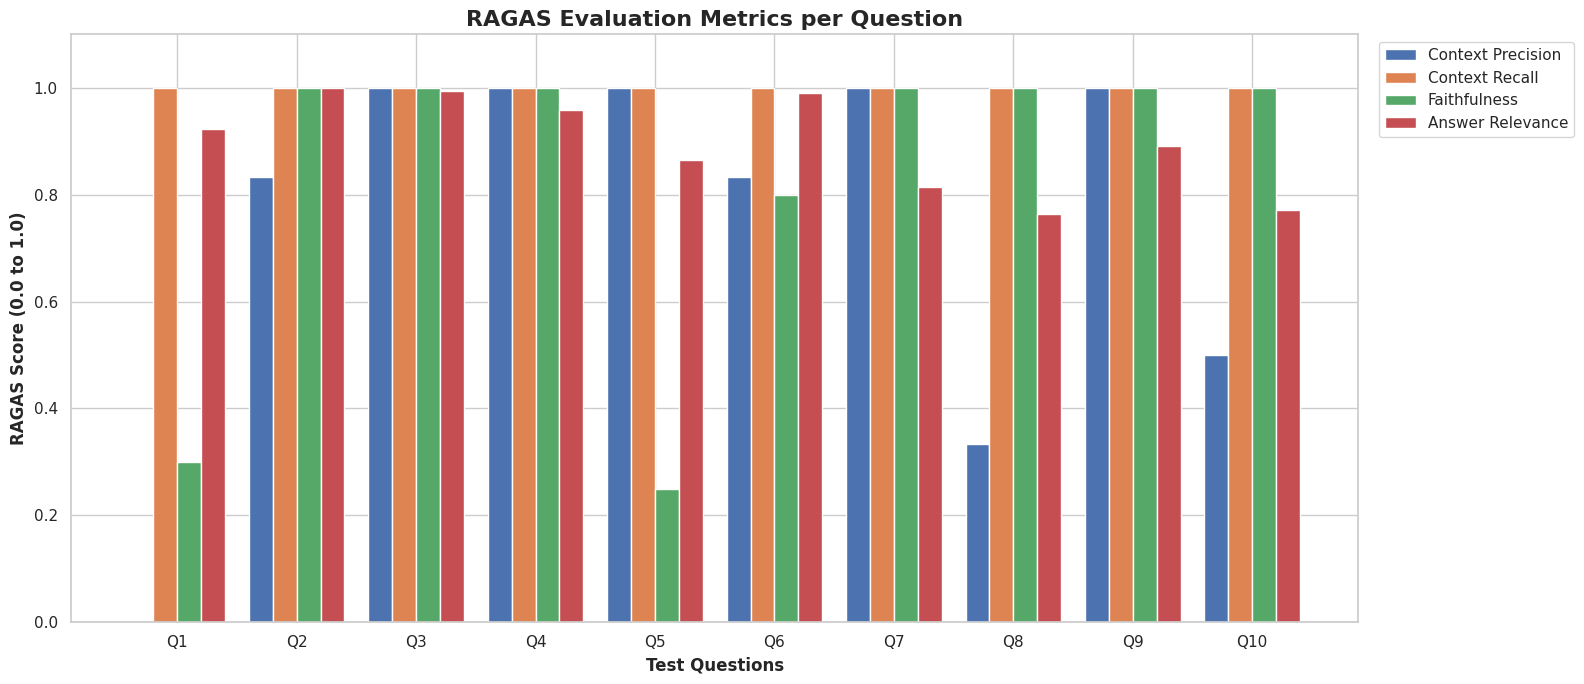

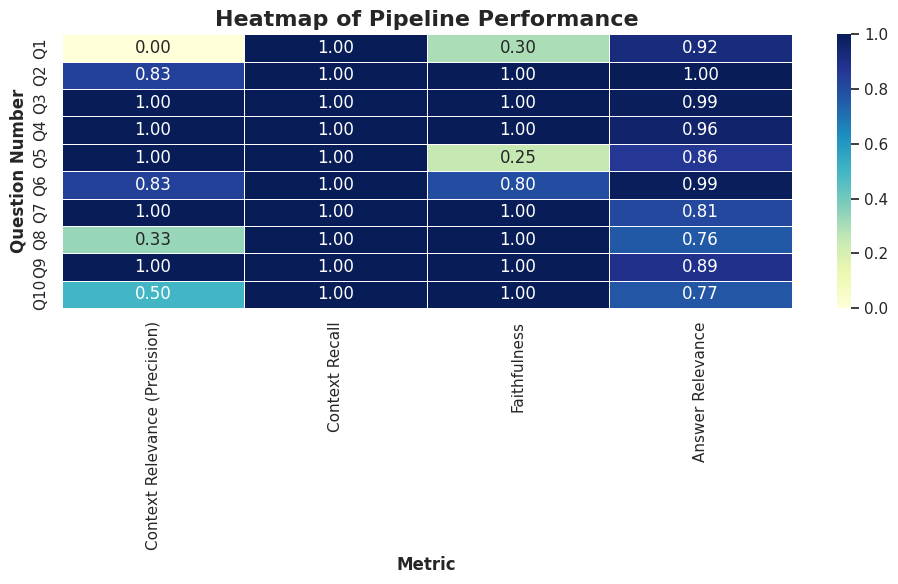

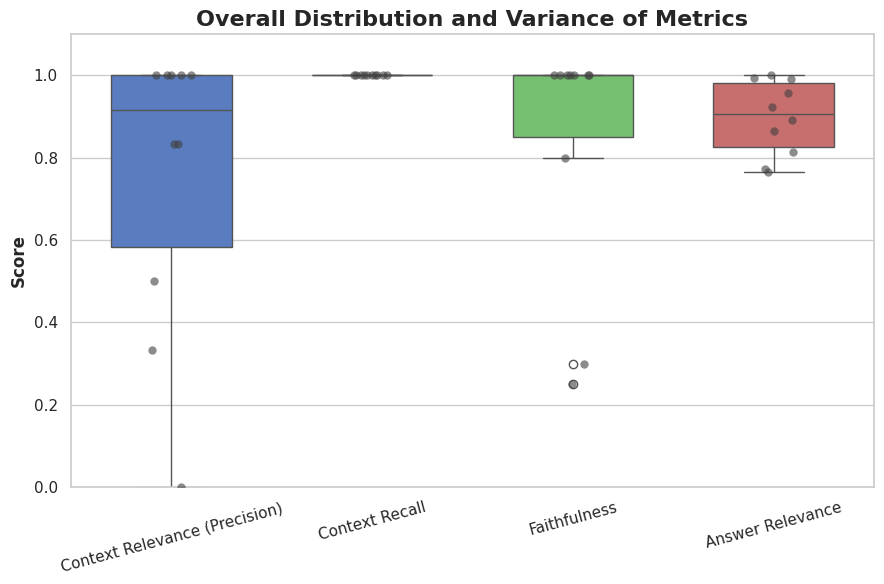


AVERAGE SYSTEM SCORES (USE THIS FOR YOUR REPORT)
Context Relevance (Precision)    0.750
Context Recall                   1.000
Faithfulness                     0.835
Answer Relevance                 0.897

DEEP DIVE: QUESTION BY QUESTION ANALYSIS

--- Q1 ---
Query: How do I prevent lateral movement if a remote worker's laptop is compromised?
Precision: 0.00 | Recall: 1.00 | Faithfulness: 0.30 | Answer Rel: 0.92

--- Q2 ---
Query: What is the purpose of a Trusted Internet Connection (TIC)?
Precision: 0.83 | Recall: 1.00 | Faithfulness: 1.00 | Answer Rel: 1.00

--- Q3 ---
Query: How does Zero Trust Architecture treat internal versus external networks?
Precision: 1.00 | Recall: 1.00 | Faithfulness: 1.00 | Answer Rel: 0.99

--- Q4 ---
Query: What role does micro-segmentation play in a Zero Trust environment?
Precision: 1.00 | Recall: 1.00 | Faithfulness: 1.00 | Answer Rel: 0.96

--- Q5 ---
Query: What are the core components of the Zero Trust logical architecture according to NIST 800-207

In [7]:
# Step 7: Plotting the graphs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. LOAD AND PREP THE DATA
# ==========================================
# Load the CSV you generated earlier
df = pd.read_csv('ZTA_Detailed_Evaluation_Report.csv')

# Create a simple "Q1, Q2, Q3..." label for the charts
df['Question_Num'] = [f"Q{i+1}" for i in range(len(df))]
metrics = ['Context Relevance (Precision)', 'Context Recall', 'Faithfulness', 'Answer Relevance']

# Ensure all metrics are numeric
for m in metrics:
    df[m] = pd.to_numeric(df[m], errors='coerce')

# Set standard plotting style
sns.set_theme(style="whitegrid")

# ==========================================
# PLOT 1: Grouped Bar Chart (Per-Question Breakdown)
# ==========================================
plt.figure(figsize=(16, 7))
x = np.arange(len(df))
width = 0.2

plt.bar(x - 1.5*width, df['Context Relevance (Precision)'], width, label='Context Precision', color='#4C72B0')
plt.bar(x - 0.5*width, df['Context Recall'], width, label='Context Recall', color='#DD8452')
plt.bar(x + 0.5*width, df['Faithfulness'], width, label='Faithfulness', color='#55A868')
plt.bar(x + 1.5*width, df['Answer Relevance'], width, label='Answer Relevance', color='#C44E52')

plt.xlabel('Test Questions', fontweight='bold', fontsize=12)
plt.ylabel('RAGAS Score (0.0 to 1.0)', fontweight='bold', fontsize=12)
plt.title('RAGAS Evaluation Metrics per Question', fontweight='bold', fontsize=16)
plt.xticks(x, df['Question_Num'], fontsize=11)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig('Plot_1_Metrics_Per_Question.png', dpi=300)
plt.show()

# ==========================================
# PLOT 2: Heatmap (Easy identification of weak spots)
# ==========================================
plt.figure(figsize=(10, 6))
heatmap_data = df.set_index('Question_Num')[metrics]
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", vmin=0, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Heatmap of Pipeline Performance', fontweight='bold', fontsize=16)
plt.ylabel('Question Number', fontweight='bold')
plt.xlabel('Metric', fontweight='bold')
plt.tight_layout()
plt.savefig('Plot_2_Performance_Heatmap.png', dpi=300)
plt.show()

# ==========================================
# PLOT 3: Boxplot (Overall System Variance)
# ==========================================
plt.figure(figsize=(9, 6))
sns.boxplot(data=df[metrics], palette='muted', width=0.6)
sns.stripplot(data=df[metrics], color=".25", size=6, alpha=0.6, jitter=True)
plt.title('Overall Distribution and Variance of Metrics', fontweight='bold', fontsize=16)
plt.ylabel('Score', fontweight='bold')
plt.xticks(rotation=15, fontsize=11)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig('Plot_3_Metrics_Distribution.png', dpi=300)
plt.show()

# ==========================================
# 4. PRINT SUMMARY FOR DISCUSSION
# ==========================================
print("\n" + "="*60)
print("AVERAGE SYSTEM SCORES (USE THIS FOR YOUR REPORT)")
print("="*60)
print(df[metrics].mean().round(3).to_string())

print("\n" + "="*60)
print("DEEP DIVE: QUESTION BY QUESTION ANALYSIS")
print("="*60)
for i in range(len(df)):
    print(f"\n--- {df['Question_Num'].iloc[i]} ---")
    print(f"Query: {df['User Query'].iloc[i]}")
    print(f"Precision: {df['Context Relevance (Precision)'].iloc[i]:.2f} | Recall: {df['Context Recall'].iloc[i]:.2f} | Faithfulness: {df['Faithfulness'].iloc[i]:.2f} | Answer Rel: {df['Answer Relevance'].iloc[i]:.2f}")

# Phase 4 Summary and Result Analysis

In this phase, we built and ran an automated evaluation pipeline using the RAGAS framework. To stick strictly to the principles of Zero Trust and keep all data private, this evaluation was executed 100% locally on the GPU using our Llama-3 (8B) model. No external cloud APIs were used for grading.

**Analysis of the Evaluation Metrics:**

* **Context Recall (Score: 1.000):** This is a perfect score. It proves our vector database (ChromaDB) and embedding model are highly effective. For all 10 test cases, the system successfully retrieved the required NIST information.
* **Answer Relevance (Score: 0.897):** The generated responses were highly relevant to the user's questions. The model stayed on topic and formatted professional guidelines rather than giving random technical output.
* **Context Precision (Score: 0.750):** While the system always found the right information (Recall), the precision score shows it sometimes struggled to rank the absolute best chunk at position #1. For example, on Question 1, it placed the most critical information at the bottom of the top-3 list. This indicates that while retrieval works, the ranking step could be improved in the future.
* **Faithfulness (Score: 0.835):** This is the most interesting result. For 7 out of 10 questions, the model scored a perfect 1.00, meaning it strictly used only the retrieved text. However, on broad questions (like Q1 and Q5), the score dropped significantly. This happened because Llama-3 realized the retrieved text was incomplete and used its own pre-trained cybersecurity knowledge to give a better answer. While this is helpful in the real world, it violates strict RAG rules, resulting in a lower faithfulness score.

Overall, the local architecture successfully retrieves accurate data and provides strong answers, though it occasionally relies on outside knowledge for very broad queries.

## Deep Dive: Question-by-Question Analysis

Here is a quick look at how the local Llama-3 model handled each specific test case. (Note: **Context Recall** was a perfect 1.00 across the board, meaning the database never failed to find the right documents).

* **Q1: How do I prevent lateral movement if a remote worker's laptop is compromised?**
    * *What happened:* The model gave a fantastic, highly relevant answer (0.92). However, it scored low on Precision (0.00) because the best text chunk was ranked at the bottom of the list. It also scored very low on Faithfulness (0.30) because Llama-3 brought in its own outside knowledge to give better security advice, breaking the strict "only use the document" rule.
* **Q2: What is the purpose of a Trusted Internet Connection (TIC)?**
    * *What happened:* A near-perfect run. The system found the exact definition, the model stuck completely to the provided text (1.00 Faithfulness), and delivered a laser-focused answer (1.00 Relevance).
* **Q3: How does Zero Trust Architecture treat internal versus external networks?**
    * *What happened:* Flawless execution. The retriever grabbed the perfect chunks immediately (1.00 Precision), and the model summarized it perfectly without hallucinating.
* **Q4: What role does micro-segmentation play in a Zero Trust environment?**
    * *What happened:* Another perfect score across almost all metrics. The local vector database clearly has excellent, easily searchable data on this specific topic.
* **Q5: What are the core components of the Zero Trust logical architecture...?**
    * *What happened:* The database found the right chunks immediately (1.00 Precision). However, Faithfulness tanked (0.25). The model likely knew the NIST 800-207 components from its pre-training and just listed them out from memory instead of strictly quoting the chunks.
* **Q6: What is the specific role of a Policy Enforcement Point (PEP)?**
    * *What happened:* A very strong performance. The retriever did a good job sorting the chunks, and the model stayed mostly grounded in the provided text while giving a highly relevant answer.
* **Q7: What is the function of the Policy Engine (PE) in the trust algorithm?**
    * *What happened:* Perfect retrieval and perfect faithfulness. The model didn't guess; it just read the text and reported back accurately.
* **Q8: How should access to individual enterprise resources be granted in ZTA?**
    * *What happened:* The system found the right info, but struggled to rank it well (Precision: 0.33), meaning the most helpful chunk was buried at the bottom. Despite that, the model still managed to give a fully faithful answer.
* **Q9: Why is device posture evaluation important before granting access...?**
    * *What happened:* Excellent performance. The retriever bubbled the most important context right to the top, and the model answered perfectly based only on that text.
* **Q10: How does Zero Trust apply the principle of least privilege?**
    * *What happened:* A solid finish. The model stuck 100% to the retrieved text (1.00 Faithfulness). The chunk ranking was average (0.50 Precision), but it didn't stop the model from drafting a solid, on-topic guideline.